# Alzheimer's Disease Stage Classification from Brain MRI Images

Classification of Alzheimer's disease stages from MRI brain scans using deep learning.  
Four classes: **NonDemented**, **VeryMildDemented**, **MildDemented**, **ModerateDemented**.

## 1. Imports and Setup

The notebook runs unchanged in the local project environment and in Google Colab. Colab uses its CUDA-enabled PyTorch installation, mounts Google Drive for persistent ResNet-50 search checkpoints, and automatically enables mixed-precision training when a GPU is active.

In [1]:
import copy
import importlib.util
import random
import shutil
import time
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, accuracy_score,
    precision_recall_fscore_support
)
from tqdm.notebook import tqdm

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

RANDOM_STATE = 1337


def set_seed(seed=RANDOM_STATE):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    # Favor repeatable results over maximum cuDNN performance.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed()

IN_COLAB = importlib.util.find_spec('google.colab') is not None
COLAB_PROJECT_DIR = Path('/content/drive/MyDrive/alzheimer-classification')
COLAB_MODEL_DIR = COLAB_PROJECT_DIR / 'models'

if IN_COLAB:
    from google.colab import drive

    drive.mount('/content/drive')
    COLAB_MODEL_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_AMP = device.type == 'cuda'

if IN_COLAB and device.type != 'cuda':
    raise RuntimeError(
        'No GPU is active. In Colab, select Runtime > Change runtime type > GPU.'
    )
print(f"Device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
print(f"Mixed precision: {USE_AMP}")
print(f"Running in Colab: {IN_COLAB}")
print(f"PyTorch version: {torch.__version__}")
print(f"Random seed: {RANDOM_STATE}")

Device: cpu
Mixed precision: False
Running in Colab: False
PyTorch version: 2.13.0+cpu
Random seed: 1337


## 2. Helper Functions

In [2]:
def get_device():
    return torch.device('cuda' if torch.cuda.is_available() else 'cpu')


def bind_gpu(data):
    dev = get_device()
    if isinstance(data, (list, tuple)):
        return [bind_gpu(item) for item in data]
    return data.to(dev, non_blocking=True)


def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    for name, layer in model.named_children():
        n = sum(p.numel() for p in layer.parameters())
        print(f"Layer: {name}, Parameters: {n}")
    print(f"Total parameters: {total}")
    return total


def state_dict_to_cpu(model):
    return {
        name: parameter.detach().cpu().clone()
        for name, parameter in model.state_dict().items()
    }


def train_model(
    model,
    criterion,
    optimizer,
    num_epochs,
    train_loader,
    val_loader,
    patience=5,
    model_name='Model',
    selection_metric='val_loss',
    use_amp=None,
):
    metrics = {
        'epoch': [],
        'train_loss': [], 'train_accuracy': [],
        'val_loss': [], 'val_accuracy': [], 'val_macro_f1': [],
        'epoch_seconds': [],
    }

    dev = get_device()
    use_amp = dev.type == 'cuda' if use_amp is None else use_amp
    scaler = torch.amp.GradScaler('cuda', enabled=use_amp)
    best_state = state_dict_to_cpu(model)
    best_macro_f1 = -1.0
    best_val_loss = float('inf')
    best_val_accuracy = 0.0
    best_epoch = 0
    epochs_without_improvement = 0

    pbar = tqdm(range(1, num_epochs + 1), desc=f'{model_name} progress')
    for epoch in pbar:
        epoch_started_at = time.perf_counter()
        pbar.set_description(f'{model_name} | Epoch {epoch}/{num_epochs}')
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        train_batches = tqdm(
            train_loader,
            desc=f'Training epoch {epoch}/{num_epochs}',
            leave=False
        )
        for inputs, labels in train_batches:
            inputs, labels = bind_gpu((inputs, labels))

            optimizer.zero_grad(set_to_none=True)
            with torch.autocast(device_type=dev.type, enabled=use_amp):
                probabilities, logits = model(inputs)
                loss = criterion(logits, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            batch_size = labels.size(0)
            train_loss += loss.item() * batch_size
            train_correct += (torch.argmax(probabilities, dim=1) == labels).sum().item()
            train_total += batch_size
            train_batches.set_postfix({'batch_loss': f'{loss.item():.4f}'})

        train_loss /= train_total
        train_accuracy = train_correct / train_total

        model.eval()
        val_loss = 0.0
        val_total = 0
        val_predictions = []
        val_targets = []

        with torch.no_grad():
            validation_batches = tqdm(
                val_loader,
                desc=f'Validation epoch {epoch}/{num_epochs}',
                leave=False
            )
            for inputs, labels in validation_batches:
                inputs, labels = bind_gpu((inputs, labels))
                with torch.autocast(device_type=dev.type, enabled=use_amp):
                    probabilities, logits = model(inputs)
                    loss = criterion(logits, labels)

                batch_size = labels.size(0)
                val_loss += loss.item() * batch_size
                val_total += batch_size
                val_predictions.extend(probabilities.argmax(dim=1).cpu().tolist())
                val_targets.extend(labels.cpu().tolist())

        val_loss /= val_total
        val_accuracy = accuracy_score(val_targets, val_predictions)
        _, _, val_macro_f1, _ = precision_recall_fscore_support(
            val_targets,
            val_predictions,
            labels=range(len(CLASS_NAMES)),
            average='macro',
            zero_division=0,
        )

        metrics['epoch'].append(epoch)
        metrics['train_loss'].append(train_loss)
        metrics['train_accuracy'].append(train_accuracy)
        metrics['val_loss'].append(val_loss)
        metrics['val_accuracy'].append(val_accuracy)
        metrics['val_macro_f1'].append(val_macro_f1)
        metrics['epoch_seconds'].append(time.perf_counter() - epoch_started_at)

        if selection_metric == 'val_macro_f1':
            improved = (
                val_macro_f1 > best_macro_f1 + 1e-12
                or (
                    abs(val_macro_f1 - best_macro_f1) <= 1e-12
                    and val_loss < best_val_loss
                )
            )
        elif selection_metric == 'val_loss':
            improved = val_loss < best_val_loss
        else:
            raise ValueError(f'Unsupported selection metric: {selection_metric}')

        if improved:
            best_state = state_dict_to_cpu(model)
            best_macro_f1 = val_macro_f1
            best_val_loss = val_loss
            best_val_accuracy = val_accuracy
            best_epoch = epoch
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        pbar.set_postfix({
            'train_loss': f'{train_loss:.4f}',
            'val_loss': f'{val_loss:.4f}',
            'val_acc': f'{val_accuracy:.4f}',
            'val_macro_f1': f'{val_macro_f1:.4f}',
            'epoch_min': f"{metrics['epoch_seconds'][-1] / 60:.1f}",
        })

        if epochs_without_improvement >= patience:
            print(f"Early stopping after epoch {epoch}.")
            break

    model.load_state_dict(best_state)
    selection = {
        'best_epoch': best_epoch,
        'val_macro_f1': best_macro_f1,
        'val_loss': best_val_loss,
        'val_accuracy': best_val_accuracy,
    }
    print(
        f'Best epoch: {best_epoch} | validation loss: {best_val_loss:.4f} | '
        f'validation macro F1: {best_macro_f1:.4f}'
    )
    return metrics, selection


def plot_training_metrics(metrics, title=''):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=13)

    axes[0].plot(metrics['epoch'], metrics['train_loss'], label='Train Loss')
    axes[0].plot(metrics['epoch'], metrics['val_loss'], label='Validation Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Loss')
    axes[0].legend()

    axes[1].plot(metrics['epoch'], metrics['train_accuracy'], label='Train Accuracy')
    axes[1].plot(metrics['epoch'], metrics['val_accuracy'], label='Validation Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title('Accuracy')
    axes[1].legend()

    plt.tight_layout()
    plt.show()


CLASS_NAMES = ['NonDemented', 'VeryMildDemented', 'MildDemented', 'ModerateDemented']


def evaluate_model(model, criterion, dataloader, title='', use_amp=None):
    model.eval()
    total_loss = 0.0
    total_samples = 0
    predicted_labels = []
    true_labels = []
    dev = get_device()
    use_amp = dev.type == 'cuda' if use_amp is None else use_amp

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = bind_gpu((inputs, labels))
            with torch.autocast(device_type=dev.type, enabled=use_amp):
                probabilities, logits = model(inputs)
                loss = criterion(logits, labels)

            batch_size = labels.size(0)
            total_loss += loss.item() * batch_size
            total_samples += batch_size

            predicted = torch.argmax(probabilities, dim=1)
            predicted_labels.extend(predicted.cpu().tolist())
            true_labels.extend(labels.cpu().tolist())

    loss = total_loss / total_samples
    accuracy = accuracy_score(true_labels, predicted_labels)
    precision, recall, f1_score, _ = precision_recall_fscore_support(
        true_labels,
        predicted_labels,
        average='weighted',
        zero_division=0
    )
    _, per_class_recall, per_class_f1, support = precision_recall_fscore_support(
        true_labels,
        predicted_labels,
        labels=range(len(CLASS_NAMES)),
        average=None,
        zero_division=0
    )
    macro_f1 = per_class_f1.mean()

    print(title)
    print(f"Loss     : {loss:.4f}")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Weighted Precision: {precision:.4f}")
    print(f"Weighted Recall   : {recall:.4f}")
    print(f"Weighted F1       : {f1_score:.4f}")
    print(f"Macro F1          : {macro_f1:.4f}")

    cm = confusion_matrix(
        true_labels,
        predicted_labels,
        labels=range(len(CLASS_NAMES))
    )
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES
    )
    plt.title(f'Confusion Matrix - {title}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

    return {
        'loss': loss,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1_score,
        'macro_f1': macro_f1,
        'per_class_recall': dict(zip(CLASS_NAMES, per_class_recall)),
        'per_class_f1': dict(zip(CLASS_NAMES, per_class_f1)),
        'support': dict(zip(CLASS_NAMES, support)),
        'true_labels': true_labels,
        'predicted_labels': predicted_labels,
    }


def compare_model_results(model_results, title):
    comparison = pd.DataFrame({
        model_name: {
            'Test Loss': results['loss'],
            'Accuracy': results['accuracy'],
            'Weighted Precision': results['precision'],
            'Weighted Recall': results['recall'],
            'Weighted F1': results['f1_score'],
            'Macro F1': results['macro_f1'],
        }
        for model_name, results in model_results.items()
    }).T
    comparison.index.name = 'Model'
    display(comparison.round(4))

    comparison[[
        'Accuracy',
        'Weighted Precision',
        'Weighted Recall',
        'Weighted F1',
        'Macro F1',
    ]].plot(kind='bar', figsize=(11, 5), ylim=(0, 1))
    plt.title(f'{title} - Overall Metrics')
    plt.xlabel('Model')
    plt.ylabel('Score')
    plt.xticks(rotation=10, ha='right')
    plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0)
    plt.tight_layout(rect=(0, 0, 0.78, 1))
    plt.show()

    per_class_recall = pd.DataFrame({
        model_name: results['per_class_recall']
        for model_name, results in model_results.items()
    })
    per_class_recall.index.name = 'Class'
    print('Per-Class Test Recall')
    display(per_class_recall.round(4))

    per_class_recall.plot(kind='bar', figsize=(11, 5), ylim=(0, 1))
    plt.title(f'{title} - Per-Class Recall')
    plt.xlabel('Class')
    plt.ylabel('Recall')
    plt.xticks(rotation=20, ha='right')
    plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0)
    plt.tight_layout(rect=(0, 0, 0.78, 1))
    plt.show()

    return comparison, per_class_recall


print("Helper functions defined.")

Helper functions defined.


## 3. Data Loading and Exploratory Data Analysis

In [3]:
LOCAL_DATASET_ROOT = Path('Alzheimer_s Dataset')
COLAB_DATASET_CACHE = Path('/content/Alzheimer_s Dataset')
COLAB_DATASET_SOURCE = COLAB_PROJECT_DIR / 'Alzheimer_s Dataset'

if (
    IN_COLAB
    and not LOCAL_DATASET_ROOT.is_dir()
    and not COLAB_DATASET_CACHE.is_dir()
    and COLAB_DATASET_SOURCE.is_dir()
):
    print('Copying the dataset from Google Drive to the Colab runtime...')
    shutil.copytree(COLAB_DATASET_SOURCE, COLAB_DATASET_CACHE)

dataset_candidates = [LOCAL_DATASET_ROOT]
if IN_COLAB:
    dataset_candidates.extend([COLAB_DATASET_CACHE, COLAB_DATASET_SOURCE])
DATASET_ROOT = next(
    (candidate for candidate in dataset_candidates if candidate.is_dir()),
    LOCAL_DATASET_ROOT,
)
KAGGLE_TRAIN_DIR = DATASET_ROOT / 'train'
KAGGLE_TEST_DIR = DATASET_ROOT / 'test'

CLASS_TO_IDX = {name: idx for idx, name in enumerate(CLASS_NAMES)}

missing_directories = [
    directory
    for split_dir in (KAGGLE_TRAIN_DIR, KAGGLE_TEST_DIR)
    for directory in [split_dir, *(split_dir / name for name in CLASS_NAMES)]
    if not directory.is_dir()
]
if missing_directories:
    missing = '\n'.join(f'  - {directory}' for directory in missing_directories)
    raise FileNotFoundError(
        'The original Kaggle train/test folders are required. Missing:\n'
        f'{missing}\n\n'
        'Download and extract tourist55/alzheimers-dataset-4-class-of-images '
        'so Alzheimer_s Dataset/train and Alzheimer_s Dataset/test exist.'
    )


def load_split(split_dir):
    paths, split_labels = [], []
    for class_name, class_idx in CLASS_TO_IDX.items():
        for img_path in sorted((split_dir / class_name).glob('*')):
            if img_path.is_file():
                paths.append(img_path)
                split_labels.append(class_idx)
    return paths, split_labels


kaggle_train_paths, kaggle_train_labels = load_split(KAGGLE_TRAIN_DIR)
kaggle_test_paths, kaggle_test_labels = load_split(KAGGLE_TEST_DIR)

EXPECTED_SPLIT_COUNTS = {
    'train': {
        'NonDemented': 2560, 'VeryMildDemented': 1792,
        'MildDemented': 717, 'ModerateDemented': 52,
    },
    'test': {
        'NonDemented': 640, 'VeryMildDemented': 448,
        'MildDemented': 179, 'ModerateDemented': 12,
    },
}
for split_name, split_labels in [
    ('train', kaggle_train_labels),
    ('test', kaggle_test_labels),
]:
    actual = Counter(split_labels)
    expected = EXPECTED_SPLIT_COUNTS[split_name]
    for class_name, class_idx in CLASS_TO_IDX.items():
        if actual[class_idx] != expected[class_name]:
            raise ValueError(
                f'Unexpected {split_name}/{class_name} count: '
                f'{actual[class_idx]} (expected {expected[class_name]}).'
            )

image_paths = kaggle_train_paths + kaggle_test_paths
labels = kaggle_train_labels + kaggle_test_labels

print(f"Dataset root:           {DATASET_ROOT.resolve()}")
print(f"Kaggle training images: {len(kaggle_train_paths)}")
print(f"Kaggle test images:     {len(kaggle_test_paths)}")
print(f"Total images:           {len(image_paths)}")
counts = Counter(labels)
for idx, name in enumerate(CLASS_NAMES):
    print(f"  {name}: {counts[idx]}")

Dataset root:           /home/jovan/University/ML/Deep-Learning-For-Human-Body-Marker-Augmentation/Alzheimer_s Dataset
Kaggle training images: 5121
Kaggle test images:     1279
Total images:           6400
  NonDemented: 3200
  VeryMildDemented: 2240
  MildDemented: 896
  ModerateDemented: 64


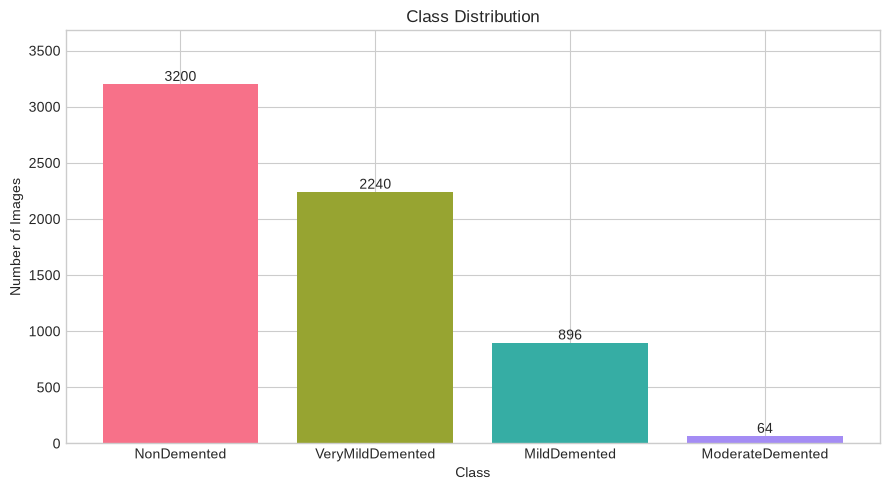

In [4]:
class_counts = [counts[i] for i in range(4)]
colors = sns.color_palette('husl', 4)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(CLASS_NAMES, class_counts, color=colors)

for bar, count in zip(bars, class_counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
            str(count), ha='center')

ax.set_title('Class Distribution')
ax.set_xlabel('Class')
ax.set_ylabel('Number of Images')
ax.set_ylim(0, max(class_counts) * 1.15)
plt.tight_layout()
plt.show()

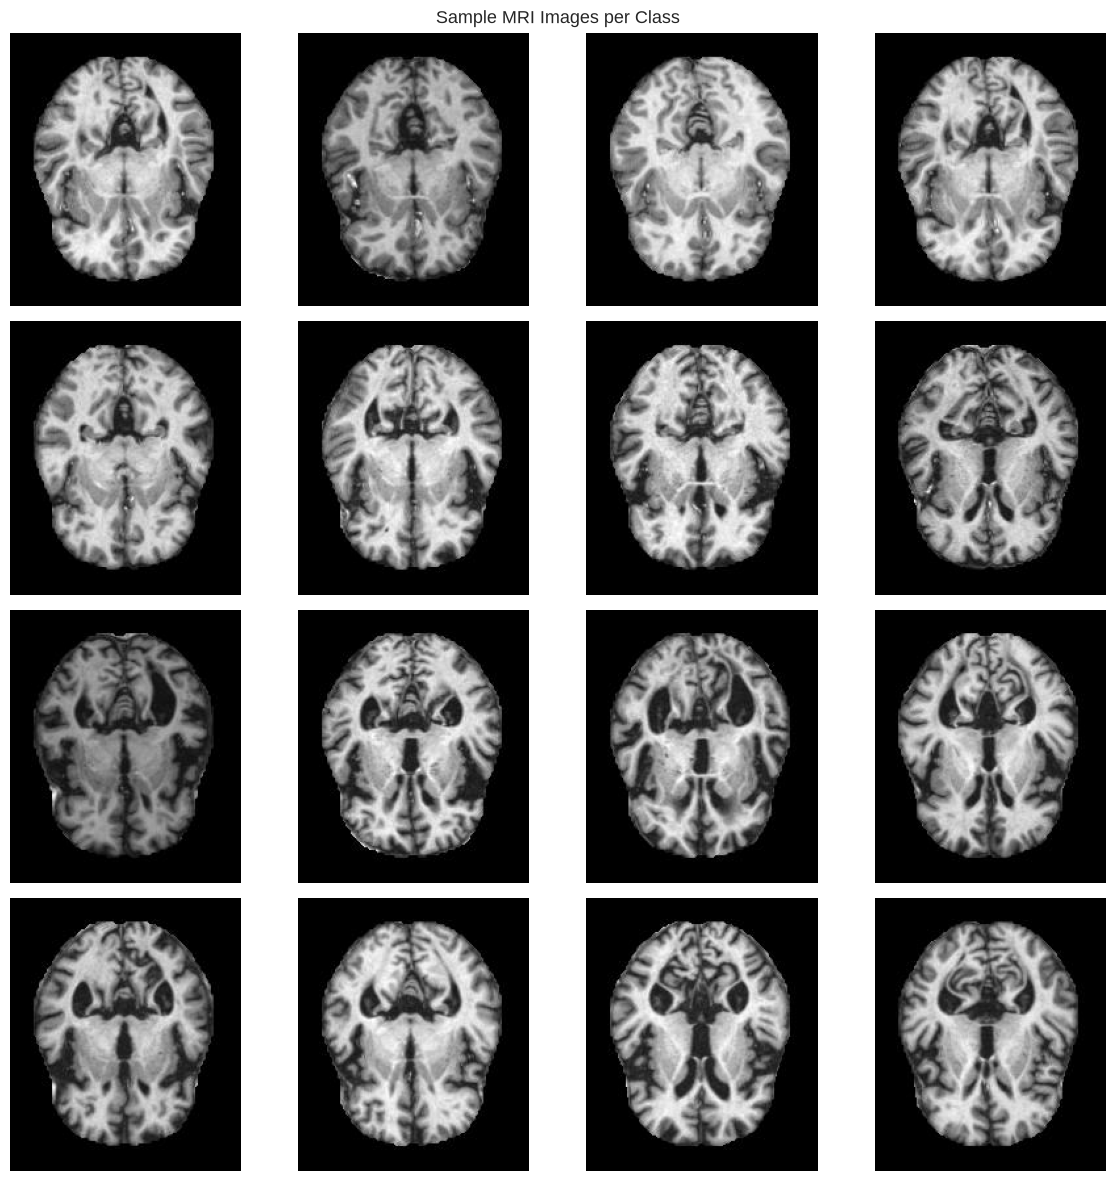

In [5]:
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
fig.suptitle('Sample MRI Images per Class', fontsize=13)

for class_idx, class_name in enumerate(CLASS_NAMES):
    class_paths = [p for p, l in zip(image_paths, labels) if l == class_idx]
    for col, img_path in enumerate(class_paths[:4]):
        ax = axes[class_idx][col]
        ax.imshow(Image.open(img_path).convert('RGB'))
        ax.axis('off')
        if col == 0:
            ax.set_ylabel(class_name, fontsize=9, rotation=90, labelpad=10)
            ax.yaxis.set_label_position('left')

plt.tight_layout()
plt.show()

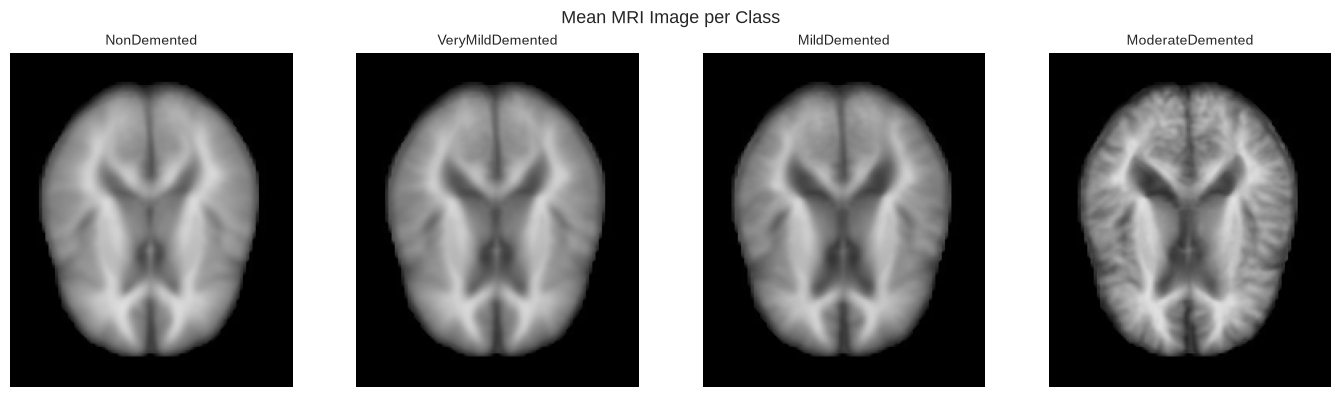

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
fig.suptitle('Mean MRI Image per Class', fontsize=13)

for class_idx, class_name in enumerate(CLASS_NAMES):
    class_paths = [p for p, l in zip(image_paths, labels) if l == class_idx]
    imgs = np.stack([
        np.array(Image.open(p).convert('L').resize((176, 208)), dtype=np.float32)
        for p in class_paths
    ])
    mean_img = imgs.mean(axis=0)
    axes[class_idx].imshow(mean_img, cmap='gray', vmin=0, vmax=255)
    axes[class_idx].set_title(class_name, fontsize=10)
    axes[class_idx].axis('off')

plt.tight_layout()
plt.show()

## 4. Train, Validation and Test Split

The original Kaggle test directory is preserved exactly and is used only for final evaluation. A stratified 20% validation subset is drawn from Kaggle's training directory; no test image participates in training, validation, normalization or augmentation.

In [7]:
all_training_paths = np.array(kaggle_train_paths, dtype=object)
all_training_labels = np.array(kaggle_train_labels, dtype=np.int64)

train_paths, validation_paths, train_labels, validation_labels = train_test_split(
    all_training_paths,
    all_training_labels,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=all_training_labels
)

train_paths, train_labels = list(train_paths), list(train_labels)
validation_paths, validation_labels = list(validation_paths), list(validation_labels)
test_paths, test_labels = list(kaggle_test_paths), list(kaggle_test_labels)

split_path_sets = {
    'training': set(train_paths),
    'validation': set(validation_paths),
    'test': set(test_paths),
}
split_pairs = [('training', 'validation'), ('training', 'test'), ('validation', 'test')]
for first_name, second_name in split_pairs:
    overlap = split_path_sets[first_name] & split_path_sets[second_name]
    if overlap:
        raise ValueError(
            f'{first_name.title()} and {second_name} contain '
            f'{len(overlap)} overlapping file paths.'
        )

if len(train_paths) + len(validation_paths) != len(kaggle_train_paths):
    raise ValueError('Training/validation split does not preserve all Kaggle training images.')

print(f"Training images (80% of Kaggle train):   {len(train_paths)}")
print(f"Validation images (20% of Kaggle train): {len(validation_paths)}")
print(f"Untouched Kaggle test images:            {len(test_paths)}")

Training images (80% of Kaggle train):   4096
Validation images (20% of Kaggle train): 1025
Untouched Kaggle test images:            1279


Split,Training,Validation,Test
Class,,,
NonDemented,2048,512,640
VeryMildDemented,1433,359,448
MildDemented,573,144,179
ModerateDemented,42,10,12


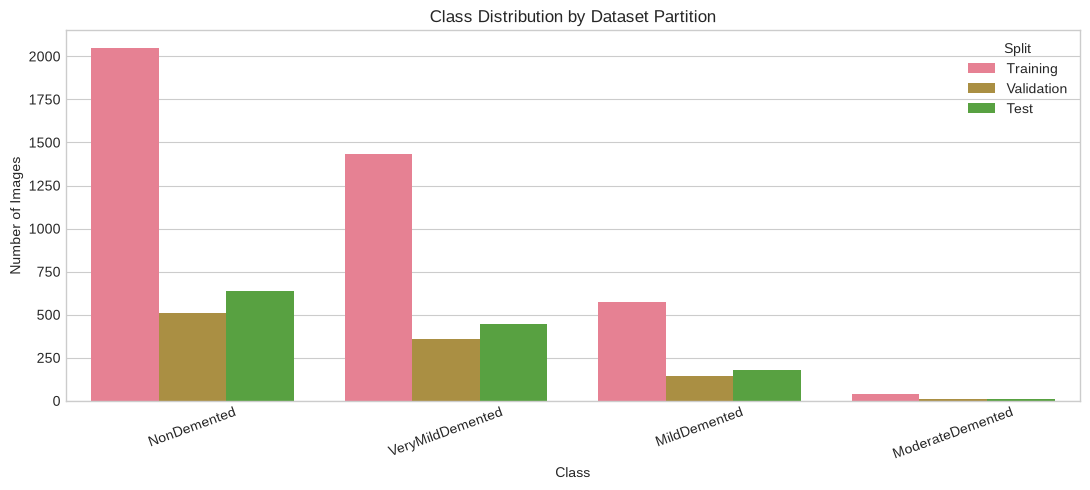

In [8]:
split_records = []
for split_name, split_labels in [
    ('Training', train_labels),
    ('Validation', validation_labels),
    ('Test', test_labels),
]:
    split_counts = Counter(split_labels)
    for class_index, class_name in enumerate(CLASS_NAMES):
        split_records.append({
            'Split': split_name,
            'Class': class_name,
            'Count': split_counts[class_index],
        })

split_distribution = pd.DataFrame(split_records)
split_table = split_distribution.pivot(index='Class', columns='Split', values='Count')
split_table = split_table.loc[CLASS_NAMES, ['Training', 'Validation', 'Test']]
display(split_table)

plt.figure(figsize=(11, 5))
sns.barplot(data=split_distribution, x='Class', y='Count', hue='Split')
plt.title('Class Distribution by Dataset Partition')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 5. Dataset Preparation and Training-Only Augmentation

Normalization statistics are calculated using only the training partition. The first CNN uses the original training images. For the second CNN, additional transformed copies are created dynamically for the MildDemented and ModerateDemented training classes.

No validation or test image is augmented or included in either training dataset.

In [9]:
pixel_sum = 0.0
pixel_squared_sum = 0.0
pixel_count = 0

for img_path in tqdm(train_paths, desc='Calculating normalization statistics'):
    image = Image.open(img_path).convert('L').resize((128, 128))
    pixels = np.asarray(image, dtype=np.float64) / 255.0
    pixel_sum += pixels.sum()
    pixel_squared_sum += np.square(pixels).sum()
    pixel_count += pixels.size

TRAIN_MEAN = pixel_sum / pixel_count
TRAIN_VARIANCE = pixel_squared_sum / pixel_count - TRAIN_MEAN ** 2
TRAIN_STD = np.sqrt(max(TRAIN_VARIANCE, 1e-12))

print(f"Training mean: {TRAIN_MEAN:.6f}")
print(f"Training standard deviation: {TRAIN_STD:.6f}")

Calculating normalization statistics:   0%|          | 0/4096 [00:00<?, ?it/s]

Training mean: 0.282495
Training standard deviation: 0.324957


In [10]:
base_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize((TRAIN_MEAN,), (TRAIN_STD,)),
])

augmentation_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05),
        scale=(0.95, 1.05)
    ),
    transforms.ToTensor(),
    transforms.Normalize((TRAIN_MEAN,), (TRAIN_STD,)),
])


AUGMENT_TARGETS = {
    CLASS_TO_IDX['MildDemented']: 700,
    CLASS_TO_IDX['ModerateDemented']: 320,
}


class MRIDataset(Dataset):
    def __init__(self, paths, labels, transform):
        self.paths = list(paths)
        self.labels = list(labels)
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, index):
        image = Image.open(self.paths[index]).convert('L').resize((128, 128))
        image = self.transform(image)
        label = int(self.labels[index])
        return image, label


class TargetedAugmentedMRIDataset(Dataset):
    def __init__(
        self,
        paths,
        labels,
        original_transform,
        augmented_transform,
        target_counts,
        random_state=RANDOM_STATE
    ):
        self.original_transform = original_transform
        self.augmented_transform = augmented_transform
        self.samples = [
            (path, int(label), False)
            for path, label in zip(paths, labels)
        ]

        rng = np.random.default_rng(random_state)
        for class_index, target_count in target_counts.items():
            class_paths = [
                path for path, label in zip(paths, labels)
                if int(label) == class_index
            ]
            additional_count = max(0, target_count - len(class_paths))

            for _ in range(additional_count):
                selected_index = rng.integers(0, len(class_paths))
                self.samples.append((class_paths[selected_index], class_index, True))

        rng.shuffle(self.samples)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        path, label, should_augment = self.samples[index]
        image = Image.open(path).convert('L').resize((128, 128))
        transform = self.augmented_transform if should_augment else self.original_transform
        image = transform(image)
        return image, label


original_train_dataset = MRIDataset(train_paths, train_labels, base_transform)
augmented_train_dataset = TargetedAugmentedMRIDataset(
    train_paths,
    train_labels,
    base_transform,
    augmentation_transform,
    AUGMENT_TARGETS
)
validation_dataset = MRIDataset(validation_paths, validation_labels, base_transform)
test_dataset = MRIDataset(test_paths, test_labels, base_transform)

print(f"Original training dataset:  {len(original_train_dataset)} images")
print(f"Augmented training dataset: {len(augmented_train_dataset)} images")

Original training dataset:  4096 images
Augmented training dataset: 4501 images


,Class,Original,Augmented
0,NonDemented,2048,2048
1,VeryMildDemented,1433,1433
2,MildDemented,573,700
3,ModerateDemented,42,320


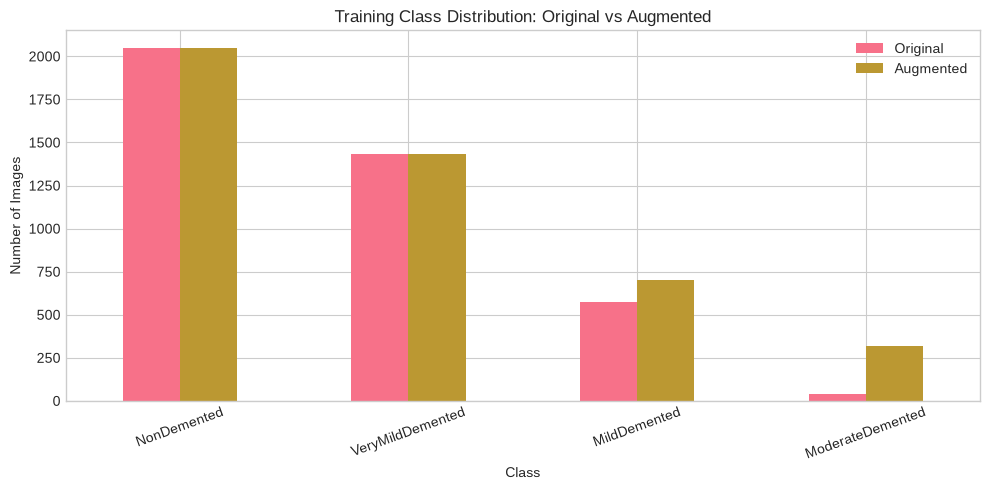

In [11]:
def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % (2 ** 32)
    np.random.seed(worker_seed)
    random.seed(worker_seed)


BATCH_SIZE = 64
NUM_WORKERS = 2
PIN_MEMORY = torch.cuda.is_available()

original_generator = torch.Generator().manual_seed(RANDOM_STATE)
augmented_generator = torch.Generator().manual_seed(RANDOM_STATE)

original_train_loader = DataLoader(
    original_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    worker_init_fn=seed_worker,
    generator=original_generator,
)
augmented_train_loader = DataLoader(
    augmented_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    worker_init_fn=seed_worker,
    generator=augmented_generator,
)
validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    worker_init_fn=seed_worker,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    worker_init_fn=seed_worker,
)

augmented_counts = Counter(label for _, label, _ in augmented_train_dataset.samples)
training_distribution = pd.DataFrame({
    'Class': CLASS_NAMES,
    'Original': [Counter(train_labels)[i] for i in range(len(CLASS_NAMES))],
    'Augmented': [augmented_counts[i] for i in range(len(CLASS_NAMES))],
})
display(training_distribution)

training_distribution.set_index('Class').plot(kind='bar', figsize=(10, 5))
plt.title('Training Class Distribution: Original vs Augmented')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

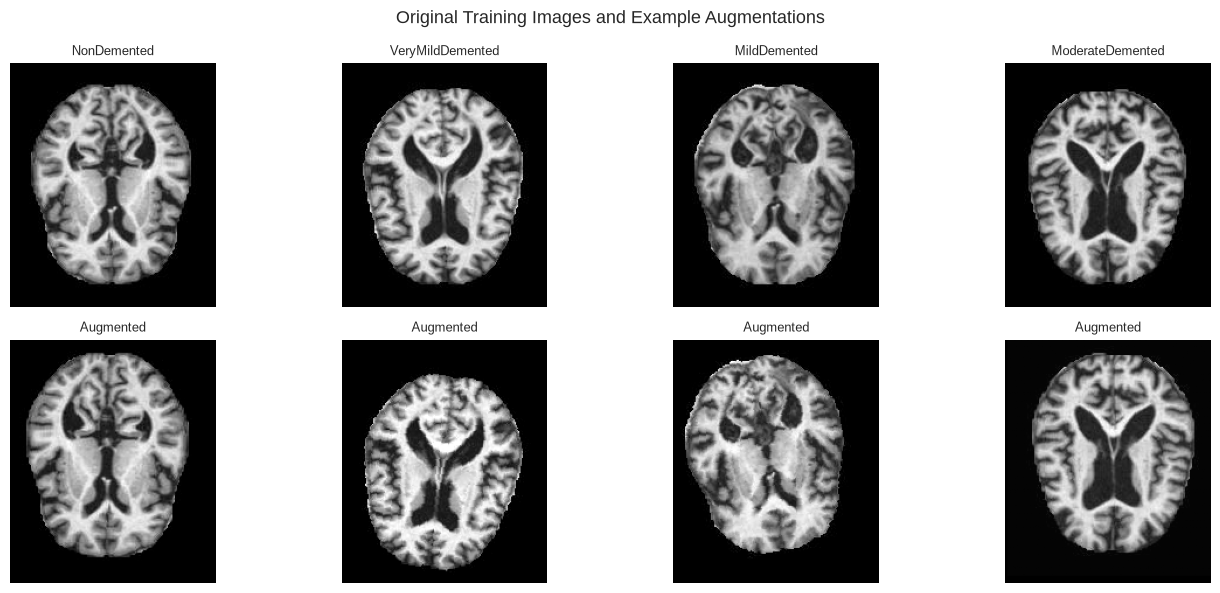

Example input batch shape: torch.Size([64, 1, 128, 128])
Example label batch shape: torch.Size([64])


In [12]:
fig, axes = plt.subplots(2, len(CLASS_NAMES), figsize=(14, 6))
fig.suptitle('Original Training Images and Example Augmentations', fontsize=13)

for class_index, class_name in enumerate(CLASS_NAMES):
    sample_path = next(
        path for path, label in zip(train_paths, train_labels)
        if label == class_index
    )
    original_image = Image.open(sample_path).convert('L')
    augmented_tensor = augmentation_transform(original_image)
    augmented_image = augmented_tensor.squeeze(0) * TRAIN_STD + TRAIN_MEAN

    axes[0, class_index].imshow(original_image, cmap='gray')
    axes[0, class_index].set_title(class_name, fontsize=9)
    axes[0, class_index].axis('off')

    axes[1, class_index].imshow(augmented_image.clamp(0, 1), cmap='gray')
    axes[1, class_index].set_title('Augmented', fontsize=9)
    axes[1, class_index].axis('off')

axes[0, 0].set_ylabel('Original')
axes[1, 0].set_ylabel('Augmented')
plt.tight_layout()
plt.show()

example_inputs, example_labels = next(iter(original_train_loader))
print(f"Example input batch shape: {example_inputs.shape}")
print(f"Example label batch shape: {example_labels.shape}")

## 6. CNN Architecture

The architecture uses convolution, activation, max pooling, dropout, flattening and fully connected layers. Repeated max pooling gradually reduces the 128×128 feature maps before they are passed to the fully connected layers.

In [13]:
class AlzheimerConvClassifier(nn.Module):
    def __init__(self, number_of_classes):
        super(AlzheimerConvClassifier, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2)
        self.dropout1 = nn.Dropout(0.25)
        self.dropout2 = nn.Dropout(0.5)
        self.fc1 = nn.Linear(in_features=64 * 8 * 8, out_features=128)
        self.fc2 = nn.Linear(in_features=128, out_features=number_of_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = self.pool(x)
        x = self.dropout1(x)

        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.dropout2(x)
        logits = self.fc2(x)
        probabilities = F.softmax(logits, dim=1)

        return probabilities, logits

In [14]:
set_seed()
model_example = AlzheimerConvClassifier(number_of_classes=len(CLASS_NAMES)).to(device)
print(model_example)
count_parameters(model_example)

with torch.no_grad():
    example_probabilities, example_logits = model_example(example_inputs.to(device))

print(f"Logit shape: {example_logits.shape}")
print(f"Probability shape: {example_probabilities.shape}")

AlzheimerConvClassifier(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout1): Dropout(p=0.25, inplace=False)
  (dropout2): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=4096, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=4, bias=True)
)
Layer: conv1, Parameters: 160
Layer: conv2, Parameters: 4640
Layer: conv3, Parameters: 18496
Layer: pool, Parameters: 0
Layer: dropout1, Parameters: 0
Layer: dropout2, Parameters: 0
Layer: fc1, Parameters: 524416
Layer: fc2, Parameters: 516
Total parameters: 548228
Logit shape: torch.Size([64, 4])
Probability shape: torch.Size([64, 4])


## 7. Training Configuration

Both networks use the same architecture, initial parameters, loss function, optimizer settings and early-stopping rule. Only their training datasets differ.

In [15]:
MAX_EPOCHS = 60
LEARNING_RATE = 0.001
PATIENCE = 10
RETRAIN_MODELS = False

MODEL_DIR = Path('models')
MODEL_DIR.mkdir(parents=True, exist_ok=True)
ORIGINAL_MODEL_PATH = MODEL_DIR / 'alzheimer_cnn_non_augmented.pt'
AUGMENTED_MODEL_PATH = MODEL_DIR / 'alzheimer_cnn_augmented.pt'

criterion = nn.CrossEntropyLoss()

set_seed()
initial_model = AlzheimerConvClassifier(number_of_classes=len(CLASS_NAMES))
initial_state = copy.deepcopy(initial_model.state_dict())
del initial_model

print(f"Maximum epochs: {MAX_EPOCHS}")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Early-stopping patience: {PATIENCE}")
print(f"Retrain existing models: {RETRAIN_MODELS}")
print(f"Model directory: {MODEL_DIR.resolve()}")

Maximum epochs: 60
Learning rate: 0.001
Early-stopping patience: 10
Retrain existing models: False
Model directory: /home/jovan/University/ML/Deep-Learning-For-Human-Body-Marker-Augmentation/models


## 8. CNN Trained on the Non-Augmented Set

The first CNN is trained only on the original images in the training partition. Its best parameters are selected using validation loss.

In [16]:
set_seed()
original_generator.manual_seed(RANDOM_STATE)
original_model = AlzheimerConvClassifier(number_of_classes=len(CLASS_NAMES)).to(device)

if ORIGINAL_MODEL_PATH.exists() and not RETRAIN_MODELS:
    checkpoint = torch.load(ORIGINAL_MODEL_PATH, map_location=device)
    original_model.load_state_dict(checkpoint['model_state_dict'])
    original_metrics = checkpoint['metrics']
    print(f"Loaded non-augmented model from {ORIGINAL_MODEL_PATH}")
else:
    original_model.load_state_dict(initial_state)
    original_optimizer = optim.Adam(original_model.parameters(), lr=LEARNING_RATE)
    original_metrics, _ = train_model(
        original_model,
        criterion,
        original_optimizer,
        MAX_EPOCHS,
        original_train_loader,
        validation_loader,
        patience=PATIENCE,
        model_name='Non-Augmented CNN'
    )
    torch.save(
        {
            'model_state_dict': original_model.state_dict(),
            'metrics': original_metrics,
            'class_names': CLASS_NAMES,
            'train_mean': float(TRAIN_MEAN),
            'train_std': float(TRAIN_STD),
            'random_state': RANDOM_STATE,
            'data_split': 'original_kaggle_test',
        },
        ORIGINAL_MODEL_PATH
    )
    print(f"Saved non-augmented model to {ORIGINAL_MODEL_PATH}")

Loaded non-augmented model from models/alzheimer_cnn_non_augmented.pt


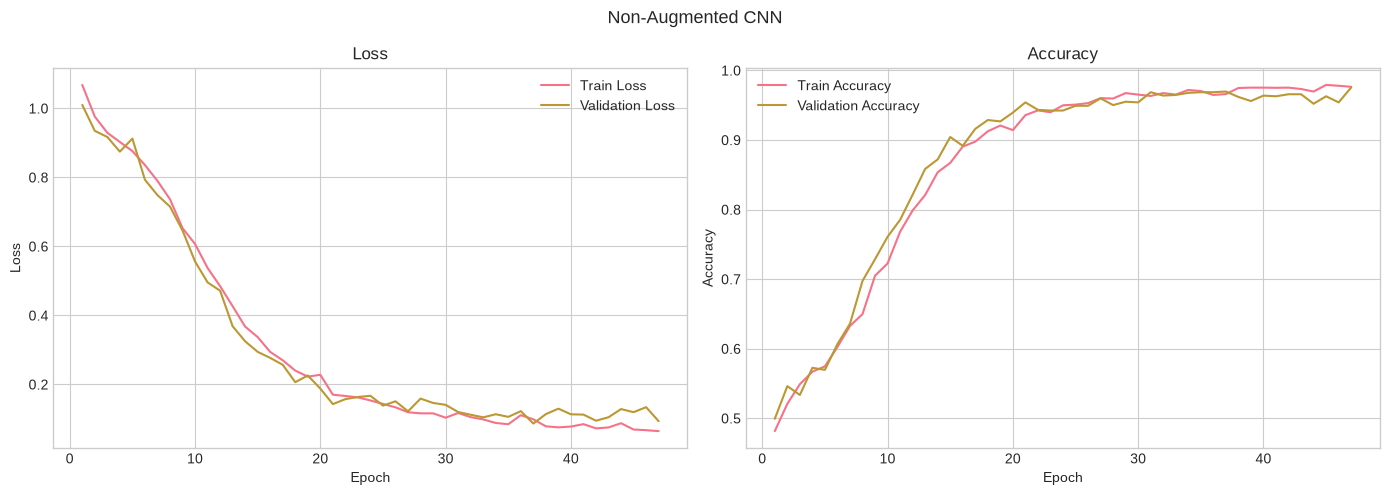

In [17]:
plot_training_metrics(original_metrics, title='Non-Augmented CNN')

## 9. CNN Trained on the Augmented Set

The second CNN starts from the same initial parameters and is trained on the targeted training-only augmented dataset. The validation set is identical to the one used for the first CNN.

In [18]:
set_seed()
augmented_generator.manual_seed(RANDOM_STATE)
augmented_model = AlzheimerConvClassifier(number_of_classes=len(CLASS_NAMES)).to(device)

if AUGMENTED_MODEL_PATH.exists() and not RETRAIN_MODELS:
    checkpoint = torch.load(AUGMENTED_MODEL_PATH, map_location=device)
    augmented_model.load_state_dict(checkpoint['model_state_dict'])
    augmented_metrics = checkpoint['metrics']
    print(f"Loaded augmented model from {AUGMENTED_MODEL_PATH}")
else:
    augmented_model.load_state_dict(initial_state)
    augmented_optimizer = optim.Adam(augmented_model.parameters(), lr=LEARNING_RATE)
    augmented_metrics, _ = train_model(
        augmented_model,
        criterion,
        augmented_optimizer,
        MAX_EPOCHS,
        augmented_train_loader,
        validation_loader,
        patience=PATIENCE,
        model_name='Augmented CNN'
    )
    torch.save(
        {
            'model_state_dict': augmented_model.state_dict(),
            'metrics': augmented_metrics,
            'class_names': CLASS_NAMES,
            'train_mean': float(TRAIN_MEAN),
            'train_std': float(TRAIN_STD),
            'random_state': RANDOM_STATE,
            'data_split': 'original_kaggle_test',
        },
        AUGMENTED_MODEL_PATH
    )
    print(f"Saved augmented model to {AUGMENTED_MODEL_PATH}")

Loaded augmented model from models/alzheimer_cnn_augmented.pt


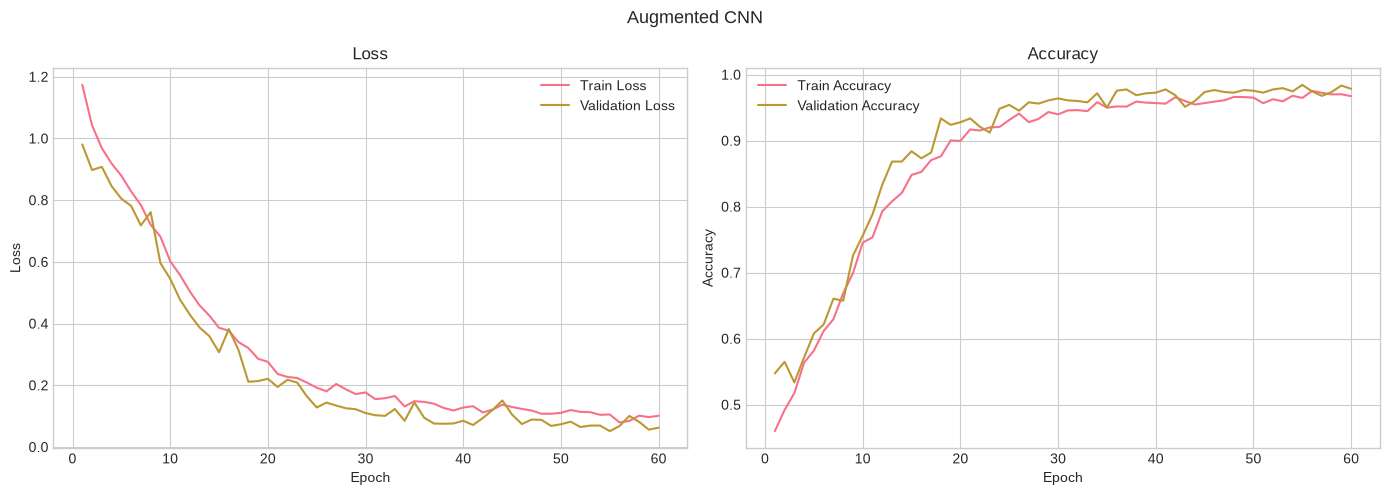

In [19]:
plot_training_metrics(augmented_metrics, title='Augmented CNN')

## 10. Test-Set Evaluation

The final models are evaluated once on Kaggle's original untouched 1,279-image test directory. The reported metrics are loss, accuracy, weighted precision, weighted recall, weighted F1 score and the confusion matrix.

Non-Augmented CNN
Loss     : 1.4661
Accuracy : 0.6865
Weighted Precision: 0.7029
Weighted Recall   : 0.6865
Weighted F1       : 0.6725
Macro F1          : 0.4934


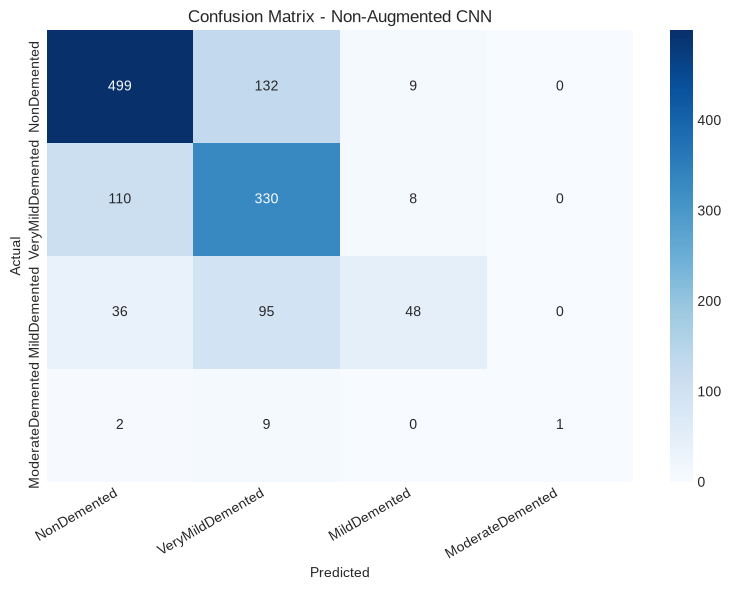

In [20]:
original_results = evaluate_model(
    original_model,
    criterion,
    test_loader,
    title='Non-Augmented CNN'
)

Augmented CNN
Loss     : 1.3804
Accuracy : 0.6458
Weighted Precision: 0.6782
Weighted Recall   : 0.6458
Weighted F1       : 0.6556
Macro F1          : 0.5678


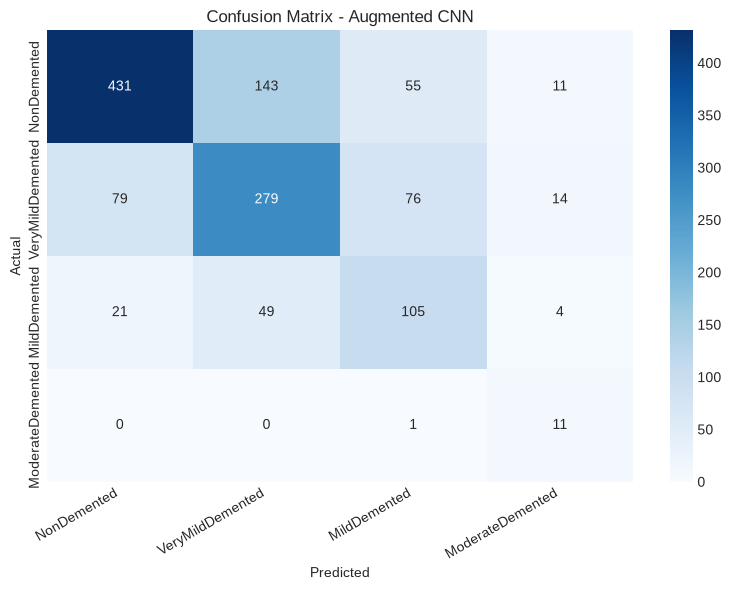

In [21]:
augmented_results = evaluate_model(
    augmented_model,
    criterion,
    test_loader,
    title='Augmented CNN'
)

,Test Loss,Accuracy,Weighted Precision,Weighted Recall,Weighted F1,Macro F1
Model,,,,,,
Non-Augmented CNN,1.4661,0.6865,0.7029,0.6865,0.6725,0.4934
Augmented CNN,1.3804,0.6458,0.6782,0.6458,0.6556,0.5678


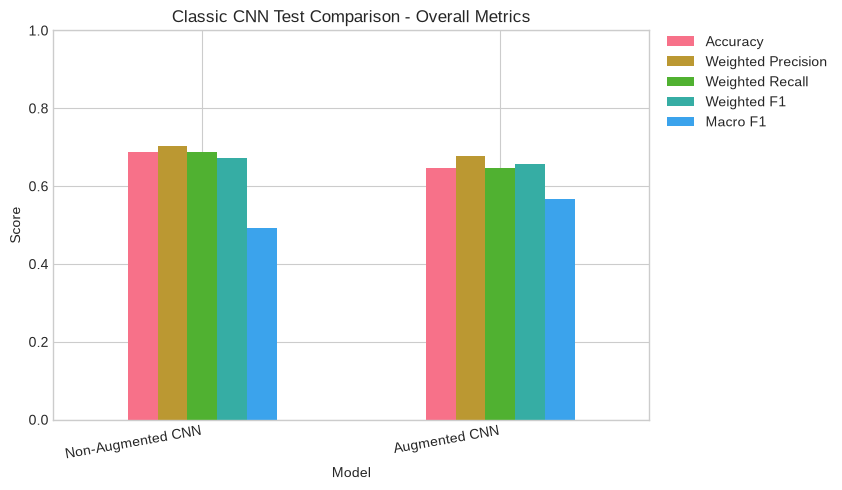

Per-Class Test Recall


,Non-Augmented CNN,Augmented CNN
Class,,
NonDemented,0.7797,0.6734
VeryMildDemented,0.7366,0.6228
MildDemented,0.2682,0.5866
ModerateDemented,0.0833,0.9167


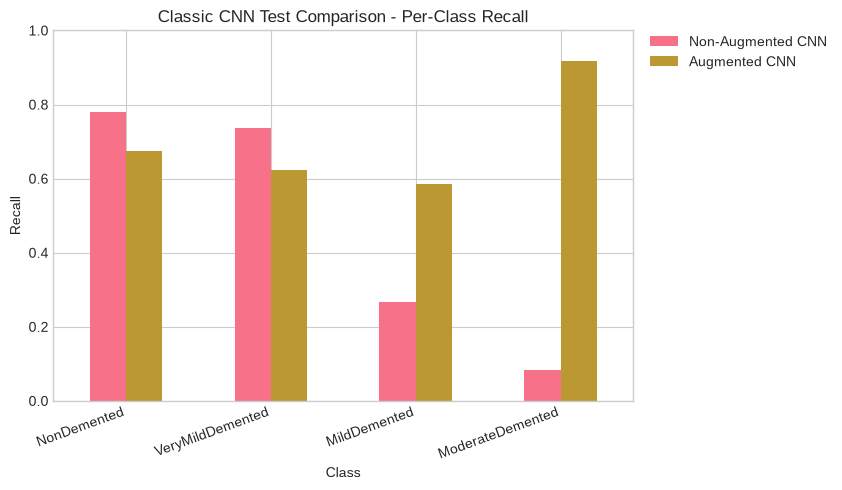

In [22]:
comparison, per_class_recall_comparison = compare_model_results(
    {
        'Non-Augmented CNN': original_results,
        'Augmented CNN': augmented_results,
    },
    title='Classic CNN Test Comparison',
)

## 11. Result Interpretation

After running both experiments, compare the learning curves, test metrics and confusion matrices. In particular, inspect whether augmentation improves recognition of the less frequent disease stages and whether either model begins to overfit according to the validation curves.

The original Kaggle test membership now matches the split used by the referenced Stanford project, making the headline test results substantially more comparable. Architecture, preprocessing, augmentation and metric-averaging differences still remain.

The `ModerateDemented` class contains only 12 Kaggle test images, so its result should be interpreted cautiously. A patient-level split would still be preferable if patient identifiers become available.

## 12. ResNet-50 Model and Search Configuration

The following experiment trains a ResNet-50 from scratch, as in the referenced Stanford project. The standard input layer is adapted for one-channel MRI images and the ImageNet classifier is replaced by two fully connected layers followed by the four-class output. The search reuses the augmented training dataset and covers the two classifier sizes and the Adam and SGD settings discussed in the paper.

In [23]:
from torchvision.models import resnet50


class AlzheimerResNet50(nn.Module):
    def __init__(self, number_of_classes, hidden_units):
        super().__init__()
        first_hidden, second_hidden = hidden_units

        self.resnet = resnet50(weights=None)
        self.resnet.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=64,
            kernel_size=7,
            stride=2,
            padding=3,
            bias=False,
        )
        input_features = self.resnet.fc.in_features
        self.resnet.fc = nn.Sequential(
            nn.Linear(input_features, first_hidden),
            nn.ReLU(inplace=True),
            nn.Linear(first_hidden, second_hidden),
            nn.ReLU(inplace=True),
            nn.Linear(second_hidden, number_of_classes),
        )

    def forward(self, x):
        logits = self.resnet(x)
        probabilities = F.softmax(logits, dim=1)
        return probabilities, logits


RESNET_HEADS = [(512, 128), (1024, 256)]
RESNET_SEARCH_CONFIGS = []
for hidden_units in RESNET_HEADS:
    for learning_rate in (1e-4, 2.25e-4, 5e-4):
        RESNET_SEARCH_CONFIGS.append({
            'hidden_units': hidden_units,
            'optimizer': 'Adam',
            'learning_rate': learning_rate,
            'betas': (0.963, 0.9997),
        })
    for learning_rate in (1e-3, 2.7e-3, 5e-3):
        RESNET_SEARCH_CONFIGS.append({
            'hidden_units': hidden_units,
            'optimizer': 'SGD',
            'learning_rate': learning_rate,
            'momentum': 0.95,
        })

RESNET_SEARCH_EPOCHS = 25
RESNET_SEARCH_PATIENCE = 6
RETRAIN_RESNET = False
RESNET_FILENAME = 'alzheimer_resnet50_best.pt'
RESNET_LOCAL_MODEL_PATH = MODEL_DIR / RESNET_FILENAME
RESNET_TRAINING_DIR = COLAB_MODEL_DIR if IN_COLAB else MODEL_DIR
RESNET_TRAINING_DIR.mkdir(parents=True, exist_ok=True)
RESNET_PERSISTENT_MODEL_PATH = RESNET_TRAINING_DIR / RESNET_FILENAME
RESNET_SEARCH_STATE_PATH = RESNET_TRAINING_DIR / 'alzheimer_resnet50_search_state.pt'

if not RETRAIN_RESNET and RESNET_LOCAL_MODEL_PATH.exists():
    RESNET_MODEL_PATH = RESNET_LOCAL_MODEL_PATH
elif not RETRAIN_RESNET and RESNET_PERSISTENT_MODEL_PATH.exists():
    RESNET_MODEL_PATH = RESNET_PERSISTENT_MODEL_PATH
else:
    RESNET_MODEL_PATH = RESNET_PERSISTENT_MODEL_PATH

print(f'ResNet-50 configurations: {len(RESNET_SEARCH_CONFIGS)}')
print(f'Maximum epochs per configuration: {RESNET_SEARCH_EPOCHS}')
print(f'Early-stopping patience: {RESNET_SEARCH_PATIENCE}')
print(f'Retrain existing ResNet-50: {RETRAIN_RESNET}')
print(f'Mixed precision: {USE_AMP}')
print(f'Model path: {RESNET_MODEL_PATH.resolve()}')

ResNet-50 configurations: 12
Maximum epochs per configuration: 25
Early-stopping patience: 6
Retrain existing ResNet-50: False
Mixed precision: False
Model path: /home/jovan/University/ML/Deep-Learning-For-Human-Body-Marker-Augmentation/models/alzheimer_resnet50_best.pt


In [24]:
set_seed()
resnet_example = AlzheimerResNet50(
    number_of_classes=len(CLASS_NAMES),
    hidden_units=RESNET_HEADS[0],
).to(device)

with torch.no_grad():
    resnet_probabilities, resnet_logits = resnet_example(example_inputs.to(device))

print(f'Logit shape: {resnet_logits.shape}')
print(f'Probability shape: {resnet_probabilities.shape}')
count_parameters(resnet_example)
del resnet_example
if torch.cuda.is_available():
    torch.cuda.empty_cache()

Logit shape: torch.Size([64, 4])
Probability shape: torch.Size([64, 4])
Layer: resnet, Parameters: 24617028
Total parameters: 24617028


## 13. Hyperparameter Search and Model Selection

Each configuration is trained with identical data, augmentation, initialization seed and early stopping. The best checkpoint within each run and the winning configuration across runs are selected by validation macro F1, with validation loss used to break ties. Only the winning model is retained and saved to avoid storing twelve large ResNet checkpoints.

In [25]:
def build_resnet_optimizer(model, config):
    if config['optimizer'] == 'Adam':
        return optim.Adam(
            model.parameters(),
            lr=config['learning_rate'],
            betas=config['betas'],
        )
    return optim.SGD(
        model.parameters(),
        lr=config['learning_rate'],
        momentum=config['momentum'],
    )


In [26]:
if RESNET_MODEL_PATH.exists() and not RETRAIN_RESNET:
    resnet_checkpoint = torch.load(
        RESNET_MODEL_PATH,
        map_location=device,
        weights_only=False,
    )
    best_resnet_config = resnet_checkpoint['config']
    best_resnet_config['hidden_units'] = tuple(best_resnet_config['hidden_units'])
    resnet_search_results = pd.DataFrame(resnet_checkpoint['search_results'])
    resnet_metrics = resnet_checkpoint['metrics']
    best_resnet_model = AlzheimerResNet50(
        number_of_classes=len(CLASS_NAMES),
        hidden_units=best_resnet_config['hidden_units'],
    ).to(device)
    best_resnet_model.load_state_dict(resnet_checkpoint['model_state_dict'])
    print(f'Loaded selected ResNet-50 from {RESNET_MODEL_PATH}')
else:
    search_rows = []
    best_resnet_state = None
    best_resnet_config = None
    resnet_metrics = None
    best_search_score = (-1.0, float('-inf'))
    completed_trials = set()

    if RESNET_SEARCH_STATE_PATH.exists() and not RETRAIN_RESNET:
        search_state = torch.load(
            RESNET_SEARCH_STATE_PATH,
            map_location='cpu',
            weights_only=False,
        )
        if search_state['search_configs'] != RESNET_SEARCH_CONFIGS:
            raise ValueError(
                'The saved ResNet search uses different configurations. '
                'Remove the search-state file or restore the original configuration list.'
            )
        search_rows = search_state['search_rows']
        completed_trials = set(search_state['completed_trials'])
        best_resnet_state = search_state['best_resnet_state']
        best_resnet_config = search_state['best_resnet_config']
        resnet_metrics = search_state['metrics']
        best_search_score = tuple(search_state['best_search_score'])
        print(
            f'Resuming ResNet-50 search with {len(completed_trials)} of '
            f'{len(RESNET_SEARCH_CONFIGS)} trials complete.'
        )

    search_progress = tqdm(
        range(1, len(RESNET_SEARCH_CONFIGS) + 1),
        desc='ResNet-50 search',
    )
    for trial_number in search_progress:
        if trial_number in completed_trials:
            continue

        config = RESNET_SEARCH_CONFIGS[trial_number - 1]
        set_seed()
        augmented_generator.manual_seed(RANDOM_STATE)
        trial_model = AlzheimerResNet50(
            number_of_classes=len(CLASS_NAMES),
            hidden_units=config['hidden_units'],
        ).to(device)
        trial_optimizer = build_resnet_optimizer(trial_model, config)
        trial_name = (
            f'ResNet trial {trial_number}/{len(RESNET_SEARCH_CONFIGS)} | '
            f"{config['optimizer']} lr={config['learning_rate']:g} "
            f"head={config['hidden_units']}"
        )

        started_at = time.perf_counter()
        trial_metrics, selection = train_model(
            trial_model,
            criterion,
            trial_optimizer,
            RESNET_SEARCH_EPOCHS,
            augmented_train_loader,
            validation_loader,
            patience=RESNET_SEARCH_PATIENCE,
            model_name=trial_name,
            selection_metric='val_macro_f1',
            use_amp=USE_AMP,
        )
        training_seconds = time.perf_counter() - started_at

        search_rows.append({
            'Trial': trial_number,
            'Optimizer': config['optimizer'],
            'Learning Rate': config['learning_rate'],
            'Hidden Units': str(config['hidden_units']),
            'Best Epoch': selection['best_epoch'],
            'Validation Macro F1': selection['val_macro_f1'],
            'Validation Loss': selection['val_loss'],
            'Validation Accuracy': selection['val_accuracy'],
            'Training Seconds': training_seconds,
        })

        trial_score = (selection['val_macro_f1'], -selection['val_loss'])
        if trial_score > best_search_score:
            best_search_score = trial_score
            best_resnet_state = state_dict_to_cpu(trial_model)
            best_resnet_config = copy.deepcopy(config)
            resnet_metrics = copy.deepcopy(trial_metrics)

        completed_trials.add(trial_number)
        search_state = {
            'search_rows': search_rows,
            'completed_trials': sorted(completed_trials),
            'best_resnet_state': best_resnet_state,
            'best_resnet_config': best_resnet_config,
            'metrics': resnet_metrics,
            'best_search_score': best_search_score,
            'search_configs': RESNET_SEARCH_CONFIGS,
            'random_state': RANDOM_STATE,
        }
        temporary_search_path = RESNET_SEARCH_STATE_PATH.with_suffix('.tmp')
        torch.save(search_state, temporary_search_path)
        temporary_search_path.replace(RESNET_SEARCH_STATE_PATH)
        search_progress.set_postfix({
            'completed': f'{len(completed_trials)}/{len(RESNET_SEARCH_CONFIGS)}',
            'best_f1': f'{best_search_score[0]:.4f}',
        })

        trial_model.cpu()
        del trial_model, trial_optimizer
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    resnet_search_results = pd.DataFrame(search_rows).sort_values(
        ['Validation Macro F1', 'Validation Loss'],
        ascending=[False, True],
    ).reset_index(drop=True)

    best_resnet_model = AlzheimerResNet50(
        number_of_classes=len(CLASS_NAMES),
        hidden_units=best_resnet_config['hidden_units'],
    ).to(device)
    best_resnet_model.load_state_dict(best_resnet_state)

    final_checkpoint = {
        'model_state_dict': best_resnet_state,
        'config': best_resnet_config,
        'search_results': resnet_search_results.to_dict('records'),
        'metrics': resnet_metrics,
        'class_names': CLASS_NAMES,
        'train_mean': float(TRAIN_MEAN),
        'train_std': float(TRAIN_STD),
        'random_state': RANDOM_STATE,
        'data_split': 'original_kaggle_test',
        'selection_metric': 'validation_macro_f1',
        'mixed_precision': USE_AMP,
    }
    temporary_model_path = RESNET_MODEL_PATH.with_suffix('.tmp')
    torch.save(final_checkpoint, temporary_model_path)
    temporary_model_path.replace(RESNET_MODEL_PATH)
    RESNET_SEARCH_STATE_PATH.unlink(missing_ok=True)
    print(f'Saved selected ResNet-50 to {RESNET_MODEL_PATH}')

display(resnet_search_results.round(4))
print('Selected configuration:')
display(pd.Series(best_resnet_config))
plot_training_metrics(resnet_metrics, title='Selected ResNet-50')

ResNet-50 search:   0%|          | 0/12 [00:00<?, ?it/s]

ResNet trial 1/12 | Adam lr=0.0001 head=(512, 128) progress:   0%|          | 0/25 [00:00<?, ?it/s]

Training epoch 1/25:   0%|          | 0/71 [00:00<?, ?it/s]

KeyboardInterrupt: 

## 14. Selected ResNet-50 Test Evaluation

After hyperparameter selection is complete, the saved winning model is evaluated once on the untouched Kaggle test set using the same metrics and confusion-matrix function as the classic CNNs.

In [ ]:
resnet_results = evaluate_model(
    best_resnet_model,
    criterion,
    test_loader,
    title='Selected ResNet-50',
)

## 15. Final Model Comparison

The selected ResNet-50 is added to the earlier test-set table and per-class recall plot, allowing its overall and minority-class performance to be compared directly with both classic CNN runs.

In [ ]:
final_comparison, final_per_class_recall = compare_model_results(
    {
        'Non-Augmented CNN': original_results,
        'Augmented CNN': augmented_results,
        'Selected ResNet-50': resnet_results,
    },
    title='Final Test Comparison',
)